## Linear NTK on projected MNIST digits

FOGD and NZK ZOGD. (Data source in this notebook is MNIST.)

In [1]:
import torch
import torch.nn as nn

from matplotlib import pyplot as plt
import numpy as np

import copy, cv2
import os, time
from datasets import load_dataset
import skimage
from PIL import Image
from scipy.io import loadmat, savemat
torch.manual_seed(0)
np.random.seed(0)

eta_fo = 1e-3  # FOGD step size
eta_zo = 1e-3  # ZOGD step size

degree = 24
sample_num = 100

digit_negative = 3
digit_positive = 5

iteration_total = 16000
function_record_iteration_list = [0, 49, 99, 199, 999, 1999, 2999, 3999, iteration_total-1]

ds = load_dataset("ylecun/mnist").with_format("np")

In [2]:
output_folder = os.path.join('output_FFN_zo_fo_mnist', 'linear_mnist_linear_{}D_{}_{}'.format(degree, digit_negative, digit_positive))
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [3]:
random_projection = np.random.normal(0.0, 0.5, (28*28, degree)) / 10.0
theta_init = torch.randn(degree, 1)

idx_negative = np.random.choice(ds['train']['image'][ds['train']['label'] == digit_negative].shape[0], sample_num)
idx_positive = np.random.choice(ds['train']['image'][ds['train']['label'] == digit_positive].shape[0], sample_num)
# extract the images and resize them to 8x8
image_negative = np.array(ds['train']['image'][ds['train']['label'] == digit_negative])[idx_negative] / 255.
image_negative = image_negative.reshape(-1, 28*28).dot(random_projection) 
image_positive = np.array(ds['train']['image'][ds['train']['label'] == digit_positive])[idx_positive] / 255.
image_positive = image_positive.reshape(-1, 28*28).dot(random_projection)

In [4]:
train_data = torch.from_numpy(np.concatenate((image_negative, image_positive), axis=0)).float()
train_label = torch.from_numpy(np.concatenate((np.zeros(sample_num), np.ones(sample_num)))).float().reshape(-1, 1)

random_idx = np.random.permutation(train_data.shape[0])
train_data = train_data[random_idx]
train_label = train_label[random_idx]

## FOGD

In [5]:
fo_theta = copy.deepcopy(theta_init)

f_0 = train_data @ fo_theta

NTK_kernal_fo = train_data @ train_data.t()

f_fo_list = torch.Tensor([])

loss_list_fo = torch.tensor([])
f_diff_list_fo = torch.tensor([])
for i in range(iteration_total):
    loss_0 = 1/2 * (f_0 - train_label).pow(2).mean()
    loss_list_fo = torch.cat((loss_list_fo, loss_0.view(1)))

    f_1 = f_0 - eta_fo / sample_num *  NTK_kernal_fo.T @ (f_0 - train_label)
    
    f_diff = f_1 - f_0
    
    if i in function_record_iteration_list:
        f_fo_list = torch.cat((f_fo_list, f_0.unsqueeze(0)))
    
    f_0 = f_1
    f_diff_list_fo = torch.cat((f_diff_list_fo, f_diff.view(1, -1)))

## NZK ZOGD

In [ ]:
NZK_list_sample = torch.tensor([]).cuda()
train_data = train_data.cuda()

for i in range(10000):
    z = torch.normal(0.0, 1.0, size=(1, degree)).cuda()
    z = z.repeat(train_data.shape[0], 1)
    
    first_term = z @ train_data.T
    second_term = z @ train_data.T
    third_term = z @ z.T
    
    NZK_temp = first_term.T * second_term * third_term

    NZK_list_sample = torch.cat((NZK_list_sample, NZK_temp.unsqueeze(0)))

NZK_kernal_zo = NZK_list_sample.mean(dim=0).cpu()
train_data = train_data.cpu()

In [7]:
zo_theta = copy.deepcopy(theta_init)

f_0 = train_data @ zo_theta
f_diff_list_zo = torch.tensor([])
loss_list_zo = torch.tensor([])

f_zo_list = torch.Tensor([])

for i in range(iteration_total):
    loss_0 = 1/2 * (f_0 - train_label).pow(2).mean()
    loss_list_zo = torch.cat((loss_list_zo, loss_0.view(1)))
    
    f_1 = f_0 - eta_zo / sample_num * NZK_kernal_zo.T @ (f_0 - train_label)
    
    f_diff = f_1 - f_0
    
    if i in function_record_iteration_list:
        f_zo_list = torch.cat((f_zo_list, f_0.unsqueeze(0)))
    
    f_0 = f_1
    f_diff_list_zo = torch.cat((f_diff_list_zo, f_diff.view(1, -1)))



In [8]:
# --------------------- save all data ---------------------
savemat(os.path.join(output_folder, 'data.mat'), {
    'theta_init': theta_init.numpy(),
    'idx_negative': idx_negative,
    'idx_positive': idx_positive,
    'random_idx': random_idx,
    'random_projection': random_projection,
    'f_fo_list': f_fo_list.numpy(),
    'f_zo_list': f_zo_list.numpy(),
    'loss_list_fo': loss_list_fo.numpy(),
    'loss_list_zo': loss_list_zo.numpy(),
    'f_diff_list_fo': f_diff_list_fo.numpy(),
    'f_diff_list_zo': f_diff_list_zo.numpy(),
    'function_record_iteration_list': function_record_iteration_list,
    'NTK_kernal_fo': NTK_kernal_fo.numpy(),
    'NZK_kernal_zo': NZK_kernal_zo.numpy()
})

## Plots (2D)

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from matplotlib import cm
from mpl_toolkits.mplot3d.axes3d import get_test_data
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Loss

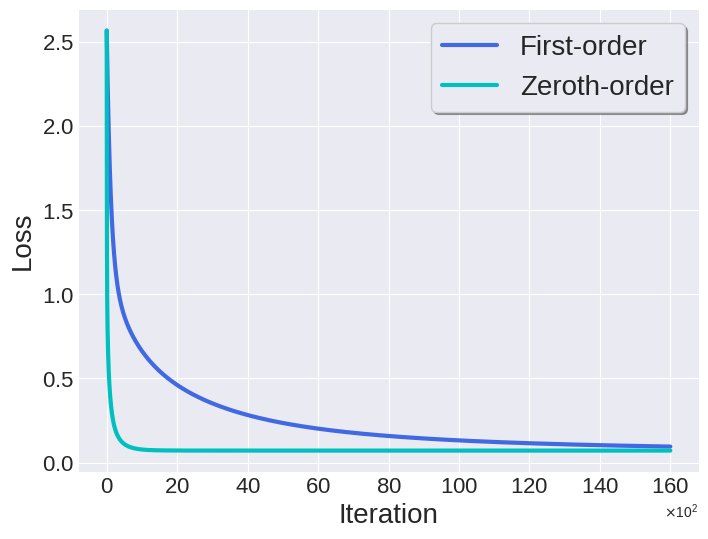

In [10]:
# plot the loss_list_fo and loss_list_zo
plt.style.use('seaborn-v0_8-darkgrid')

sf = plt.figure(figsize=(8,6), dpi=100)
ax = sf.add_subplot()
plt.plot(loss_list_fo[:].detach().numpy(),color='royalblue',label='First-order', linewidth=3)
plt.plot(loss_list_zo[:].detach().numpy(),color='c',label='Zeroth-order', linewidth=3)

plt.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=16)
plt.ticklabel_format(style='sci', scilimits=(0,2), axis='y',useMathText=True)
plt.ticklabel_format(style='sci', scilimits=(2,2), axis='x',useMathText=True)
plt.legend(fancybox=True, shadow=True,fontsize=20, frameon=True)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.show()

sf.savefig(os.path.join(output_folder,'loss.pdf'), bbox_inches='tight')

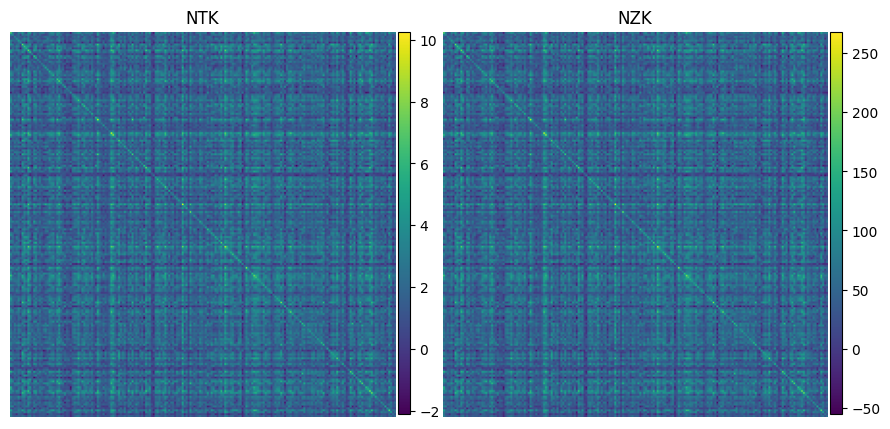

In [11]:
# return to defualt style
plt.style.use('default')
grid = plt.GridSpec(1, 2, wspace = -0.13, hspace = 0.05)

fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(grid[0, 0])
norm_fo = plt.Normalize(NTK_kernal_fo.min(), NTK_kernal_fo.max())
ax.imshow(NTK_kernal_fo.detach().numpy(), label='NTK')
ax.title.set_text('NTK')
ax.axis('off')

cbar_ax = fig.add_axes([0.495, 0.115, 0.01, 0.765])
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm_fo)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)

ax = fig.add_subplot(grid[0, 1])
norm_zo = plt.Normalize(NZK_kernal_zo.min(), NZK_kernal_zo.max())
ax.imshow(NZK_kernal_zo.detach().numpy(), label='NZK')
ax.title.set_text('NZK')
ax.axis('off')

cbar_ax = fig.add_axes([0.855, 0.115, 0.01, 0.765])
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm_zo)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)
plt.show()
# save the figure
fig.savefig(os.path.join(output_folder,'NTK_NZK.pdf'), bbox_inches='tight')